In [7]:
# Model configuration: Add new models here with just their name and path
# The code will automatically collect score files from each path
MODELS_CONFIG = [
    {
        'name': 'xlsr_conformertcm_mdt_baseline',
        'path': "/nvme1/hungdx/code/Lightning-hydra/logs/results/benchmark_telephony/S_241214_conf-1",
        'enabled': True
    },
    {
        'name': 'xlsr_conformertcm_mdt_lora',
        'path': "/nvme1/hungdx/code/Lightning-hydra/logs/results/benchmark_telephony/ConformerTCM_MDT_LoRA_LargeCorpus_MoreElevenlabs",
        'enabled': False
    },
        {
        'name': 'xlsr_conformertcm_mdt_8khz',
        'path': "/nvme1/hungdx/code/Lightning-hydra/logs/results/benchmark_telephony/8khz_xlsr_conformertcm_mdt",
        'enabled': False  # Set to True to include this model
    },
    {
        'name': 'xlsr_conformertcm_mdt_lora_lowpass_gpu',
        'path': "/nvme1/hungdx/code/Lightning-hydra/logs/results/benchmark_telephony/lora_lowpass_gpu",
        'enabled': True
    },
    {
        'name': 'xlsr_conformertcm_mdt_lora_rawboostla',
        'path': "/nvme1/hungdx/code/Lightning-hydra/logs/results/benchmark_telephony/lora_augmented_la_e17_best",
        'enabled': True
    },
]

In [8]:
import sys
import os
import pandas as pd
import numpy as np
sys.path.append("/nvme1/hungdx/code/Lightning-hydra/notebooks/benchmark_telephony")
import eval_metrics_DF as em
from sklearn.metrics import accuracy_score

def collect_score_files(model_path, file_prefix="m_ailabs_"):
    """Automatically collect score files from a model directory"""
    if not os.path.exists(model_path):
        print(f"Warning: Path does not exist: {model_path}")
        return []
    return sorted([
        os.path.join(model_path, file) 
        for file in os.listdir(model_path) 
        if file.startswith(file_prefix) and os.path.isfile(os.path.join(model_path, file))
    ])

# Automatically collect score files for all enabled models
models_config = {}
for model in MODELS_CONFIG:
    if model.get('enabled', True):
        score_files = collect_score_files(model['path'])
        if score_files:
            models_config[model['name']] = score_files
            print(f"✓ {model['name']}: Found {len(score_files)} score file(s)")
        else:
            print(f"⚠ {model['name']}: No score files found")

# Protocol metadata configuration
PROTOCOL_METADATAS = [
    "/nvme1/hungdx/code/Lightning-hydra/data/benchmark_telephony/m_ailabs_v7_only_la_codec_aug/protocol.txt",
    # "/nvme1/hungdx/code/Lightning-hydra/data/benchmark_telephony/m_ailabs_v8_only_la_codec_aug/protocol.txt",
    # "/nvme1/hungdx/code/Lightning-hydra/data/benchmark_telephony/m_ailabs_v9_only_la_codec_aug/protocol.txt"
]

# Group filters for evaluation
GROUP_FILTERS = [
    "LA_C1",
    "LA_C2",
    "LA_C3",
    "LA_C4",
    "LA_C5",
    "LA_C7", 
]

✓ xlsr_conformertcm_mdt_baseline: Found 3 score file(s)
✓ xlsr_conformertcm_mdt_lora_lowpass_gpu: Found 1 score file(s)
✓ xlsr_conformertcm_mdt_lora_rawboostla: Found 1 score file(s)


In [9]:
def read_protocol_file(protocol_path):
    """Read protocol file and return DataFrame"""
    data = []
    with open(protocol_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) >= 3:
                file_path = parts[0]
                subset = parts[1]
                label = parts[2]
                if subset == 'eval':  # Only use eval subset
                    data.append({'path': file_path, 'label': label})
    return pd.DataFrame(data)

def read_score_file(score_path):
    """Read score file and return DataFrame"""
    data = []
    with open(score_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) >= 3:
                # Has 2 scores: take last 2 as scores, rest as path
                try:
                    spoof_score = float(parts[-2])
                    bona_score = float(parts[-1])
                    file_path = ' '.join(parts[:-2])
                    data.append({'path': file_path, 'spoof_score': spoof_score, 'bona_score': bona_score})
                except ValueError:
                    continue
            elif len(parts) >= 2:
                # Has 1 score: use same value for both
                try:
                    score = float(parts[-1])
                    file_path = ' '.join(parts[:-1])
                    data.append({'path': file_path, 'spoof_score': score, 'bona_score': score})
                except ValueError:
                    continue
    return pd.DataFrame(data)

def calculate_group_metrics(protocol_df, score_df, group_name):
    """Calculate EER and accuracy for a specific group"""
    # Filter protocol by group
    group_protocol = protocol_df[protocol_df['path'].str.startswith(group_name + '/')].copy()
    
    if len(group_protocol) == 0:
        return None
    
    # Merge with scores
    merged = group_protocol.merge(score_df, on='path', how='inner')
    
    if len(merged) == 0:
        return None
    
    # Separate bonafide and spoof scores for EER calculation
    bonafide_scores = merged[merged['label'] == 'bonafide']['bona_score'].values
    spoof_scores = merged[merged['label'] == 'spoof']['bona_score'].values
    
    if len(bonafide_scores) == 0 or len(spoof_scores) == 0:
        return None
    
    # Calculate EER using bona_score
    eer, threshold = em.compute_eer(bonafide_scores, spoof_scores)
    
    # Calculate accuracy: if spoof_score < bona_score, predict bonafide, else spoof
    predictions = np.where(merged['spoof_score'] < merged['bona_score'], 'bonafide', 'spoof')
    accuracy = accuracy_score(merged['label'], predictions) * 100
    
    return {
        'eer': eer * 100,
        'accuracy': accuracy,
        'threshold': threshold,
        'n_samples': len(merged),
        'n_bonafide': len(bonafide_scores),
        'n_spoof': len(spoof_scores)
    }


In [10]:
# Results storage
results = []

# Process each model
for model_name, score_files in models_config.items():
    print(f"\nProcessing model: {model_name}")
    
    # Process each protocol version
    for protocol_path in PROTOCOL_METADATAS:
        # Extract version name from protocol path (e.g., m_ailabs_v7_only_la_codec_aug)
        version_name = os.path.basename(os.path.dirname(protocol_path))
        
        # Find corresponding score file
        matching_score_file = None
        for score_file in score_files:
            if version_name in os.path.basename(score_file):
                matching_score_file = score_file
                break
        
        if matching_score_file is None:
            print(f"  Warning: No matching score file found for {version_name}")
            continue
        
        print(f"  Processing {version_name}...")
        
        # Read protocol and score files
        try:
            protocol_df = read_protocol_file(protocol_path)
            score_df = read_score_file(matching_score_file)
        except Exception as e:
            print(f"  Error reading files: {e}")
            continue
        
        # Calculate metrics for each group
        for group_name in GROUP_FILTERS:
            metrics = calculate_group_metrics(protocol_df, score_df, group_name)
            if metrics is not None:
                results.append({
                    'model': model_name,
                    'version': version_name,
                    'group': group_name,
                    'eer': metrics['eer'],
                    'accuracy': metrics['accuracy'],
                    'threshold': metrics['threshold'],
                    'n_samples': metrics['n_samples'],
                    'n_bonafide': metrics['n_bonafide'],
                    'n_spoof': metrics['n_spoof']
                })

# Convert to DataFrame
results_df = pd.DataFrame(results)
print(f"\nTotal results: {len(results_df)}")



Processing model: xlsr_conformertcm_mdt_baseline
  Processing m_ailabs_v7_only_la_codec_aug...

Processing model: xlsr_conformertcm_mdt_lora_lowpass_gpu
  Processing m_ailabs_v7_only_la_codec_aug...

Processing model: xlsr_conformertcm_mdt_lora_rawboostla
  Processing m_ailabs_v7_only_la_codec_aug...

Total results: 18


In [11]:
# Display results table
if len(results_df) > 0:
    # Create a pivot table for easier viewing
    pivot_eer = results_df.pivot_table(
        values='eer',
        index=['group', 'version'],
        columns='model',
        aggfunc='first'
    )
    
    pivot_accuracy = results_df.pivot_table(
        values='accuracy',
        index=['group', 'version'],
        columns='model',
        aggfunc='first'
    )
    
    print("=" * 100)
    print("EER (%) by Group and Version")
    print("=" * 100)
    print(pivot_eer.round(2))
    
    print("\n" + "=" * 100)
    print("Accuracy (%) by Group and Version")
    print("=" * 100)
    print(pivot_accuracy.round(2))
    
    # Also show full detailed results
    print("\n" + "=" * 100)
    print("Detailed Results")
    print("=" * 100)
    display_cols = ['model', 'version', 'group', 'eer', 'accuracy', 'n_samples']
    print(results_df[display_cols].to_string(index=False))
else:
    print("No results to display")


EER (%) by Group and Version
model                                xlsr_conformertcm_mdt_baseline  \
group version                                                         
LA_C1 m_ailabs_v7_only_la_codec_aug                            5.59   
LA_C2 m_ailabs_v7_only_la_codec_aug                           10.45   
LA_C3 m_ailabs_v7_only_la_codec_aug                           10.03   
LA_C4 m_ailabs_v7_only_la_codec_aug                            8.04   
LA_C5 m_ailabs_v7_only_la_codec_aug                            9.82   
LA_C7 m_ailabs_v7_only_la_codec_aug                            8.42   

model                                xlsr_conformertcm_mdt_lora_lowpass_gpu  \
group version                                                                 
LA_C1 m_ailabs_v7_only_la_codec_aug                                    6.64   
LA_C2 m_ailabs_v7_only_la_codec_aug                                   10.27   
LA_C3 m_ailabs_v7_only_la_codec_aug                                    9.96   
LA_C4 m

In [12]:
# Optional: Save results to CSV
if len(results_df) > 0:
    output_path = "/nvme1/hungdx/code/Lightning-hydra/logs/results/benchmark_telephony/group_analysis_results.csv"
    results_df.to_csv(output_path, index=False)
    print(f"Results saved to: {output_path}")
else:
    print("No results to save")


Results saved to: /nvme1/hungdx/code/Lightning-hydra/logs/results/benchmark_telephony/group_analysis_results.csv


# Visualize 1 version

ANALYSIS: Model Comparison for Version v7
Models to analyze: ['xlsr_conformertcm_mdt_baseline', 'xlsr_conformertcm_mdt_lora_lowpass_gpu', 'xlsr_conformertcm_mdt_lora_rawboostla']
Groups to analyze: ['LA_C1', 'LA_C2', 'LA_C3', 'LA_C4', 'LA_C5', 'LA_C7']

COMPARISON WITH LA_C1 (Baseline Group) - Version v7

Difference from LA_C1 for each group:
                                 model group  accuracy_diff_vs_la_c1  eer_diff_vs_la_c1  accuracy  accuracy_la_c1       eer  eer_la_c1
        xlsr_conformertcm_mdt_baseline LA_C1                0.000000           0.000000 93.578846       93.578846  5.592308   5.592308
        xlsr_conformertcm_mdt_baseline LA_C2               -7.821154           4.857692 85.757692       93.578846 10.450000   5.592308
        xlsr_conformertcm_mdt_baseline LA_C3               -7.251923           4.438462 86.326923       93.578846 10.030769   5.592308
        xlsr_conformertcm_mdt_baseline LA_C4               -4.492308           2.446154 89.086538       93.578846  

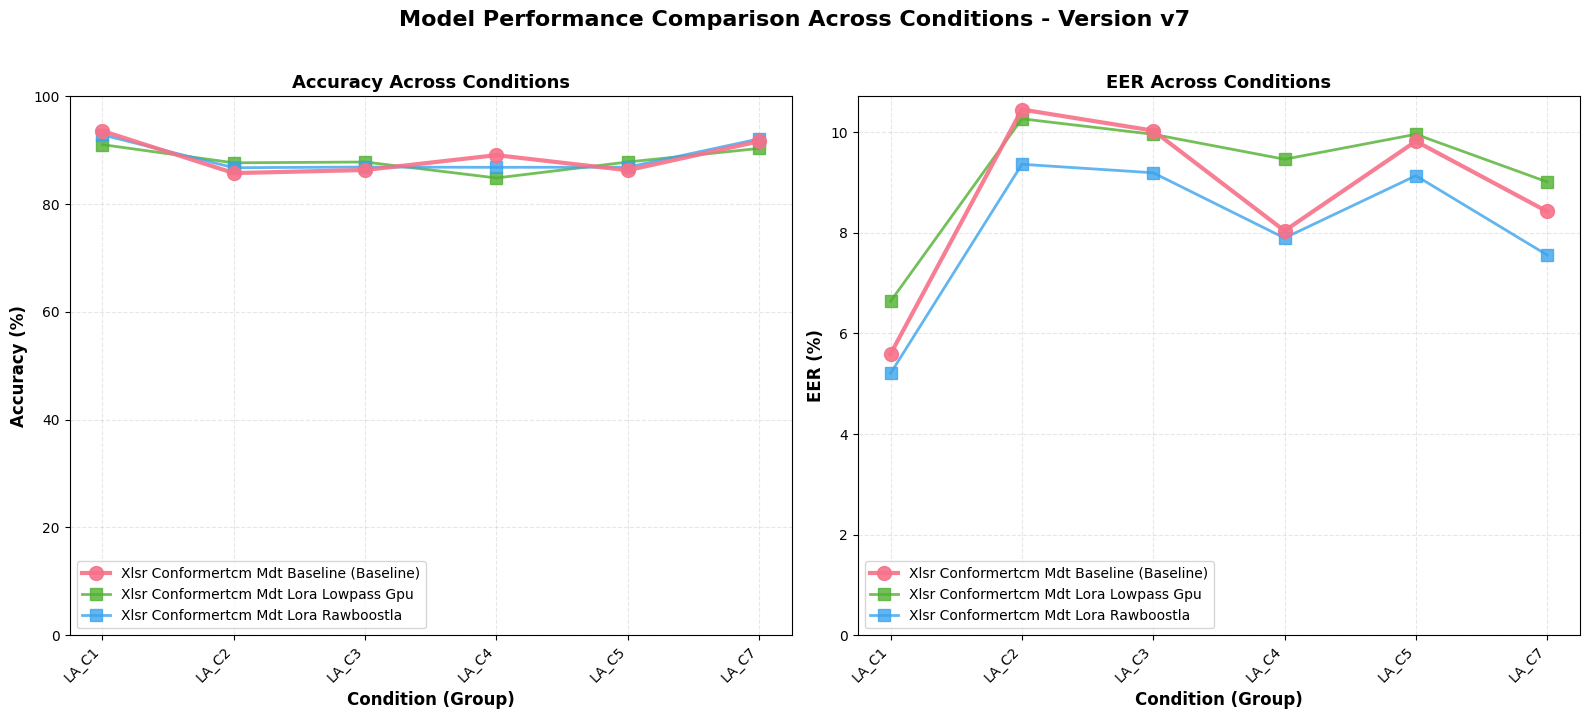

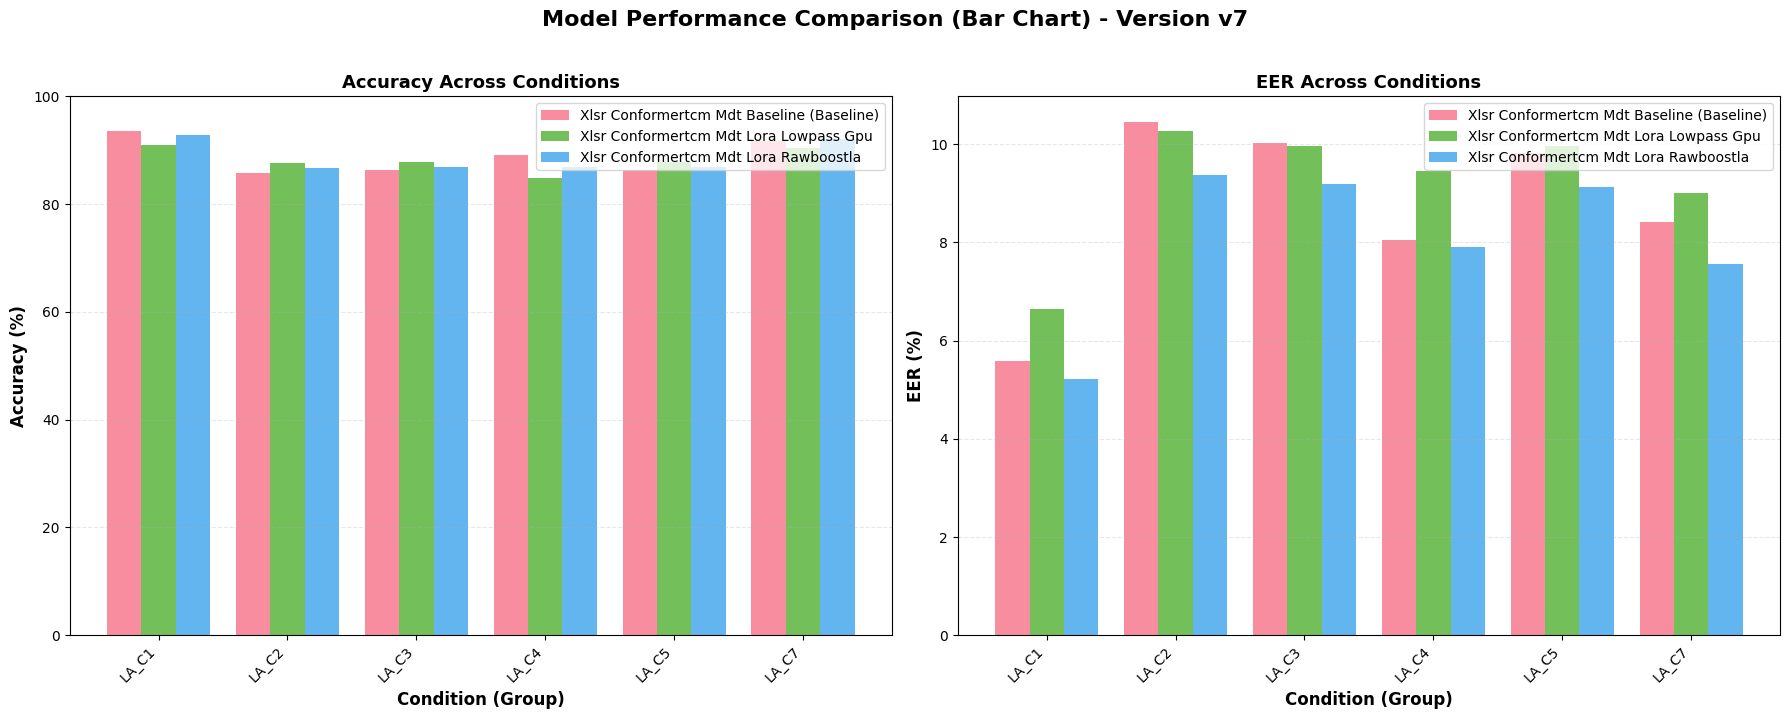

In [13]:
# Analysis: Compare models and groups for a specific version
# Configuration: Choose which version to analyze

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

VERSION_TO_ANALYZE = 'v7'  # Change to 'v8', 'v9', etc. as needed

print("=" * 80)
print(f"ANALYSIS: Model Comparison for Version {VERSION_TO_ANALYZE}")
print("=" * 80)

# Ensure results_df is loaded
if 'results_df' not in locals() and 'results_df' not in globals():
    csv_path = "/nvme1/hungdx/code/Lightning-hydra/logs/results/benchmark_telephony/group_analysis_results.csv"
    results_df = pd.read_csv(csv_path)
    
    # Add version_short if not present - use same logic as visualization setup
    if 'version_short' not in results_df.columns:
        # Use extract_version_short if available, otherwise define inline
        if 'extract_version_short' not in globals():
            import re
            VERSION_MAPPING = {
                'm_ailabs_v7_only_la_codec_aug': 'v7',
                'm_ailabs_v8_only_la_codec_aug': 'v8',
                'm_ailabs_v9_only_la_codec_aug': 'v9',
            }
            def extract_version_short(version_name):
                if version_name in VERSION_MAPPING:
                    return VERSION_MAPPING[version_name]
                match = re.search(r'v(\d+)', version_name)
                if match:
                    return f"v{match.group(1)}"
                return version_name[:10]
        
        results_df['version_short'] = results_df['version'].apply(extract_version_short)
        
        # Order versions properly
        VERSION_ORDER = ['v7', 'v8', 'v9']
        available_versions = sorted(results_df['version_short'].unique())
        version_order = [v for v in VERSION_ORDER if v in available_versions] + \
                        [v for v in available_versions if v not in VERSION_ORDER]
        results_df['version_short'] = pd.Categorical(results_df['version_short'], categories=version_order, ordered=True)

# Filter results_df to only include the selected version
if 'version_short' in results_df.columns:
    results_df_filtered = results_df[results_df['version_short'] == VERSION_TO_ANALYZE].copy()
    print(f"\nFiltering data for version: {VERSION_TO_ANALYZE}")
    print(f"Original rows: {len(results_df)}, Filtered rows: {len(results_df_filtered)}")
    if len(results_df_filtered) == 0:
        print(f"WARNING: No data found for version {VERSION_TO_ANALYZE}!")
        print(f"Available versions: {results_df['version_short'].unique()}")
    results_df = results_df_filtered
else:
    print("WARNING: version_short column not found in results_df!")

# Get models and groups from filtered data
models = sorted(results_df['model'].unique()) if len(results_df) > 0 else []
groups = sorted(results_df['group'].unique()) if len(results_df) > 0 else []

if len(results_df) == 0:
    print("ERROR: No data available for analysis!")
else:
    print(f"Models to analyze: {models}")
    print(f"Groups to analyze: {groups}")

# Compare each group with LA_C1 (baseline group) for the selected version
comparison_with_la_c1 = []

for model in models:
    model_data = results_df[results_df['model'] == model].copy()
    
    # Get LA_C1 baseline for this model and version
    la_c1_data = model_data[model_data['group'] == 'LA_C1']
    if len(la_c1_data) == 0:
        print(f"WARNING: No LA_C1 data found for model {model} in version {VERSION_TO_ANALYZE}")
        continue
    
    la_c1_acc = la_c1_data.iloc[0]['accuracy']
    la_c1_eer = la_c1_data.iloc[0]['eer']
    
    # Compare all other groups with LA_C1
    for group in groups:
        group_data = model_data[model_data['group'] == group]
        if len(group_data) == 0:
            continue
        
        group_acc = group_data.iloc[0]['accuracy']
        group_eer = group_data.iloc[0]['eer']
        
        comparison_with_la_c1.append({
            'model': model,
            'version': VERSION_TO_ANALYZE,
            'group': group,
            'accuracy_diff_vs_la_c1': group_acc - la_c1_acc,
            'eer_diff_vs_la_c1': group_eer - la_c1_eer,
            'accuracy': group_acc,
            'accuracy_la_c1': la_c1_acc,
            'eer': group_eer,
            'eer_la_c1': la_c1_eer
        })

comparison_df = pd.DataFrame(comparison_with_la_c1)

# Display results
if len(comparison_df) > 0:
    print("\n" + "=" * 80)
    print(f"COMPARISON WITH LA_C1 (Baseline Group) - Version {VERSION_TO_ANALYZE}")
    print("=" * 80)
    print("\nDifference from LA_C1 for each group:")
    print(comparison_df[['model', 'group', 'accuracy_diff_vs_la_c1', 'eer_diff_vs_la_c1', 
                         'accuracy', 'accuracy_la_c1', 'eer', 'eer_la_c1']].to_string(index=False))
    
    # Save to CSV
    comparison_path = f"/nvme1/hungdx/code/Lightning-hydra/logs/results/benchmark_telephony/comparison_with_la_c1_{VERSION_TO_ANALYZE}.csv"
    comparison_df.to_csv(comparison_path, index=False)
    print(f"\nResults saved to: {comparison_path}")
else:
    print("\nWARNING: No comparison data generated!")
# Visualization: Plot actual EER/Accuracy values for all models across conditions
if len(results_df) > 0:
    # Get model display names helper
    def get_model_display_name(model_name):
        if 'MODEL_DISPLAY_NAMES' in globals():
            return MODEL_DISPLAY_NAMES.get(model_name, model_name.replace('_', ' ').title())
        if 'model_names' in globals():
            return model_names.get(model_name, model_name.replace('_', ' ').title())
        return model_name.replace('_', ' ').title()
    
    model_display_names = {m: get_model_display_name(m) for m in models}
    
    # Prepare data for plotting: get actual EER and Accuracy values for each model and group
    groups_ordered = sorted(groups)  # Order groups for consistent plotting
    x_pos = np.arange(len(groups_ordered))
    
    # Separate baseline model from others
    baseline_model = None
    for model in models:
        if 'baseline' in model.lower():
            baseline_model = model
            break
    
    # If no explicit baseline, use first model as baseline
    if baseline_model is None and len(models) > 0:
        baseline_model = models[0]
    
    # Create color palette
    model_colors = sns.color_palette("husl", len(models))
    model_color_map = {model: color for model, color in zip(models, model_colors)}
    
    # Plot 1: Line plot showing trends across conditions
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'Model Performance Comparison Across Conditions - Version {VERSION_TO_ANALYZE}', 
                fontsize=16, fontweight='bold', y=1.02)
    
    # Plot Accuracy
    for model in models:
        model_data = results_df[results_df['model'] == model].sort_values('group')
        accuracy_values = []
        for group in groups_ordered:
            group_data = model_data[model_data['group'] == group]
            if len(group_data) > 0:
                accuracy_values.append(group_data.iloc[0]['accuracy'])
            else:
                accuracy_values.append(np.nan)
        
        # Plot baseline with different style (thicker line, different marker)
        if model == baseline_model:
            ax1.plot(groups_ordered, accuracy_values, 
                    marker='o', linewidth=3, markersize=10,
                    label=model_display_names[model] + ' (Baseline)',
                    color=model_color_map[model],
                    alpha=0.9, zorder=10)
        else:
            ax1.plot(groups_ordered, accuracy_values,
                    marker='s', linewidth=2, markersize=8,
                    label=model_display_names[model],
                    color=model_color_map[model],
                    alpha=0.8)
    
    ax1.set_xlabel('Condition (Group)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax1.set_title('Accuracy Across Conditions', fontsize=13, fontweight='bold')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(groups_ordered, rotation=45, ha='right')
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_ylim(bottom=0, top=100)
    
    # Plot EER
    for model in models:
        model_data = results_df[results_df['model'] == model].sort_values('group')
        eer_values = []
        for group in groups_ordered:
            group_data = model_data[model_data['group'] == group]
            if len(group_data) > 0:
                eer_values.append(group_data.iloc[0]['eer'])
            else:
                eer_values.append(np.nan)
        
        # Plot baseline with different style
        if model == baseline_model:
            ax2.plot(groups_ordered, eer_values,
                    marker='o', linewidth=3, markersize=10,
                    label=model_display_names[model] + ' (Baseline)',
                    color=model_color_map[model],
                    alpha=0.9, zorder=10)
        else:
            ax2.plot(groups_ordered, eer_values,
                    marker='s', linewidth=2, markersize=8,
                    label=model_display_names[model],
                    color=model_color_map[model],
                    alpha=0.8)
    
    ax2.set_xlabel('Condition (Group)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('EER (%)', fontsize=12, fontweight='bold')
    ax2.set_title('EER Across Conditions', fontsize=13, fontweight='bold')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(groups_ordered, rotation=45, ha='right')
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.set_ylim(bottom=0)
    
    plt.tight_layout()
    plt.show()
    
    # Plot 2: Grouped bar chart for easier value comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f'Model Performance Comparison (Bar Chart) - Version {VERSION_TO_ANALYZE}', 
                fontsize=16, fontweight='bold', y=1.02)
    
    # Grouped bar chart for Accuracy
    width = 0.8 / len(models)
    x_pos = np.arange(len(groups_ordered))
    
    for idx, model in enumerate(models):
        model_data = results_df[results_df['model'] == model].sort_values('group')
        accuracy_values = []
        for group in groups_ordered:
            group_data = model_data[model_data['group'] == group]
            accuracy_values.append(group_data.iloc[0]['accuracy'] if len(group_data) > 0 else 0)
        
        offset = (idx - len(models) / 2 + 0.5) * width
        bars = ax1.bar(x_pos + offset, accuracy_values, width,
                      label=model_display_names[model] + (' (Baseline)' if model == baseline_model else ''),
                      color=model_color_map[model],
                      alpha=0.8)
    
    ax1.set_xlabel('Condition (Group)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax1.set_title('Accuracy Across Conditions', fontsize=13, fontweight='bold')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(groups_ordered, rotation=45, ha='right')
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax1.set_ylim(bottom=0, top=100)
    
    # Grouped bar chart for EER
    for idx, model in enumerate(models):
        model_data = results_df[results_df['model'] == model].sort_values('group')
        eer_values = []
        for group in groups_ordered:
            group_data = model_data[model_data['group'] == group]
            eer_values.append(group_data.iloc[0]['eer'] if len(group_data) > 0 else 0)
        
        offset = (idx - len(models) / 2 + 0.5) * width
        bars = ax2.bar(x_pos + offset, eer_values, width,
                      label=model_display_names[model] + (' (Baseline)' if model == baseline_model else ''),
                      color=model_color_map[model],
                      alpha=0.8)
    
    ax2.set_xlabel('Condition (Group)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('EER (%)', fontsize=12, fontweight='bold')
    ax2.set_title('EER Across Conditions', fontsize=13, fontweight='bold')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(groups_ordered, rotation=45, ha='right')
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax2.set_ylim(bottom=0)
    
    plt.tight_layout()
    plt.show()
else:
    print("\nNo data available for visualization.")


# Visualize multiple version

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# VISUALIZATION CONFIGURATION
# ============================================================================
# Add model display names here. If a model is not listed, a default name will be generated
MODEL_DISPLAY_NAMES = {
    'xlsr_conformertcm_mdt_8khz': '8kHz Model',
    'xlsr_conformertcm_mdt_lora': 'LoRA Model',
    'xlsr_conformertcm_mdt_baseline': 'Baseline Model',
    'xlsr_conformertcm_mdt_lora_lowpass_gpu': 'LoRA Lowpass GPU',
    'xlsr_conformertcm_mdt_lora_rawboostla': 'LoRA RawBoost LA',
}

# Version mapping: full version name -> short display name
# If a version is not listed, it will be auto-extracted (e.g., m_ailabs_v7_... -> v7)
VERSION_MAPPING = {
    'm_ailabs_v7_only_la_codec_aug': 'v7',
    'm_ailabs_v8_only_la_codec_aug': 'v8',
    'm_ailabs_v9_only_la_codec_aug': 'v9',
}

# Version display order (for categorical ordering)
VERSION_ORDER = ['v7', 'v8', 'v9']

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================
def get_model_display_name(model_name):
    """Get display name for a model, with fallback to auto-generated name"""
    if model_name in MODEL_DISPLAY_NAMES:
        return MODEL_DISPLAY_NAMES[model_name]
    # Auto-generate: convert snake_case to Title Case
    return model_name.replace('_', ' ').title()

def extract_version_short(version_name):
    """Extract short version name from full version name (e.g., m_ailabs_v7_... -> v7)"""
    # Try mapping first
    if version_name in VERSION_MAPPING:
        return VERSION_MAPPING[version_name]
    # Auto-extract: look for v\d+ pattern
    match = re.search(r'v(\d+)', version_name)
    if match:
        return f"v{match.group(1)}"
    # Fallback: use first 10 chars
    return version_name[:10]

# ============================================================================
# LOAD DATA
# ============================================================================
try:
    # Check if results_df exists and has data
    if 'results_df' not in locals() and 'results_df' not in globals():
        raise NameError("results_df not found")
    if len(results_df) == 0:
        raise ValueError("results_df is empty")
except (NameError, ValueError):
    # Load from CSV
    csv_path = "/nvme1/hungdx/code/Lightning-hydra/logs/results/benchmark_telephony/group_analysis_results.csv"
    try:
        results_df = pd.read_csv(csv_path)
        print(f"Loaded {len(results_df)} rows from CSV")
    except Exception as e:
        print(f"Error loading CSV: {e}")
        print("Please run the previous cells to generate results_df first")
        raise

# Debug: Check data
print(f"Total rows in results_df: {len(results_df)}")
print(f"Columns: {results_df.columns.tolist()}")
if len(results_df) > 0:
    print(f"Models: {results_df['model'].unique()}")
    print(f"Groups: {results_df['group'].unique()}")
    print(f"Versions: {results_df['version'].unique()}")
    print(f"Sample data:")
    print(results_df.head())

# ============================================================================
# PREPARE DATA FOR VISUALIZATION
# ============================================================================
# Create simplified version names for better visualization
results_df['version_short'] = results_df['version'].apply(extract_version_short)

# Order versions properly (only include versions that exist in data)
available_versions = sorted(results_df['version_short'].unique())
version_order = [v for v in VERSION_ORDER if v in available_versions] + \
                [v for v in available_versions if v not in VERSION_ORDER]
results_df['version_short'] = pd.Categorical(results_df['version_short'], categories=version_order, ordered=True)

# Debug: Check version_short after mapping
print(f"\nVersion mapping check:")
print(f"Unique versions: {results_df['version'].unique()}")
print(f"Unique version_short: {results_df['version_short'].unique()}")
print(f"Null values in version_short: {results_df['version_short'].isna().sum()}")

# ============================================================================
# SETUP PLOTTING VARIABLES
# ============================================================================
models = sorted(results_df['model'].unique())
model_names = {model: get_model_display_name(model) for model in models}
groups = sorted(results_df['group'].unique())
group_colors = sns.color_palette("Set2", len(groups))

print(f"\nModel display names:")
for model, display_name in model_names.items():
    print(f"  {model} -> {display_name}")


Total rows in results_df: 18
Columns: ['model', 'version', 'group', 'eer', 'accuracy', 'threshold', 'n_samples', 'n_bonafide', 'n_spoof']
Models: ['xlsr_conformertcm_mdt_lora' 'xlsr_conformertcm_mdt_baseline'
 'xlsr_conformertcm_mdt_lora_lowpass_gpu']
Groups: ['LA_C1' 'LA_C2' 'LA_C3' 'LA_C4' 'LA_C5' 'LA_C7']
Versions: ['m_ailabs_v7_only_la_codec_aug']
Sample data:
                        model                        version  group       eer  \
0  xlsr_conformertcm_mdt_lora  m_ailabs_v7_only_la_codec_aug  LA_C1  5.419231   
1  xlsr_conformertcm_mdt_lora  m_ailabs_v7_only_la_codec_aug  LA_C2  9.988462   
2  xlsr_conformertcm_mdt_lora  m_ailabs_v7_only_la_codec_aug  LA_C3  9.830769   
3  xlsr_conformertcm_mdt_lora  m_ailabs_v7_only_la_codec_aug  LA_C4  8.034615   
4  xlsr_conformertcm_mdt_lora  m_ailabs_v7_only_la_codec_aug  LA_C5  9.746154   

    accuracy  threshold  n_samples  n_bonafide  n_spoof  
0  93.090385   1.750133      52000       26000    26000  
1  85.750000   2.762621      5


Creating EER graph...
Models to plot: ['xlsr_conformertcm_mdt_8khz', 'xlsr_conformertcm_mdt_baseline', 'xlsr_conformertcm_mdt_lora']
Groups to plot: ['LA_C1', 'LA_C2', 'LA_C3', 'LA_C4', 'LA_C5', 'LA_C7']

Model xlsr_conformertcm_mdt_8khz: 18 rows
  Group LA_C1: 3 rows, versions: ['v7', 'v8', 'v9'], EER values: [18.176923076923078, 12.870714285714286, 12.830993965643279]
  Group LA_C2: 3 rows, versions: ['v7', 'v8', 'v9'], EER values: [21.776923076923076, 16.759761904761906, 15.25124204887599]
  Group LA_C3: 3 rows, versions: ['v7', 'v8', 'v9'], EER values: [21.346153846153847, 16.62642857142857, 14.838748459127643]
  Group LA_C4: 3 rows, versions: ['v7', 'v8', 'v9'], EER values: [18.896153846153847, 13.683333333333334, 12.89160730149]
  Group LA_C5: 3 rows, versions: ['v7', 'v8', 'v9'], EER values: [21.33846153846154, 16.5, 14.891643666448722]
  Group LA_C7: 3 rows, versions: ['v7', 'v8', 'v9'], EER values: [20.326923076923077, 16.613809523809525, 14.602194996330109]

Model xlsr_confo

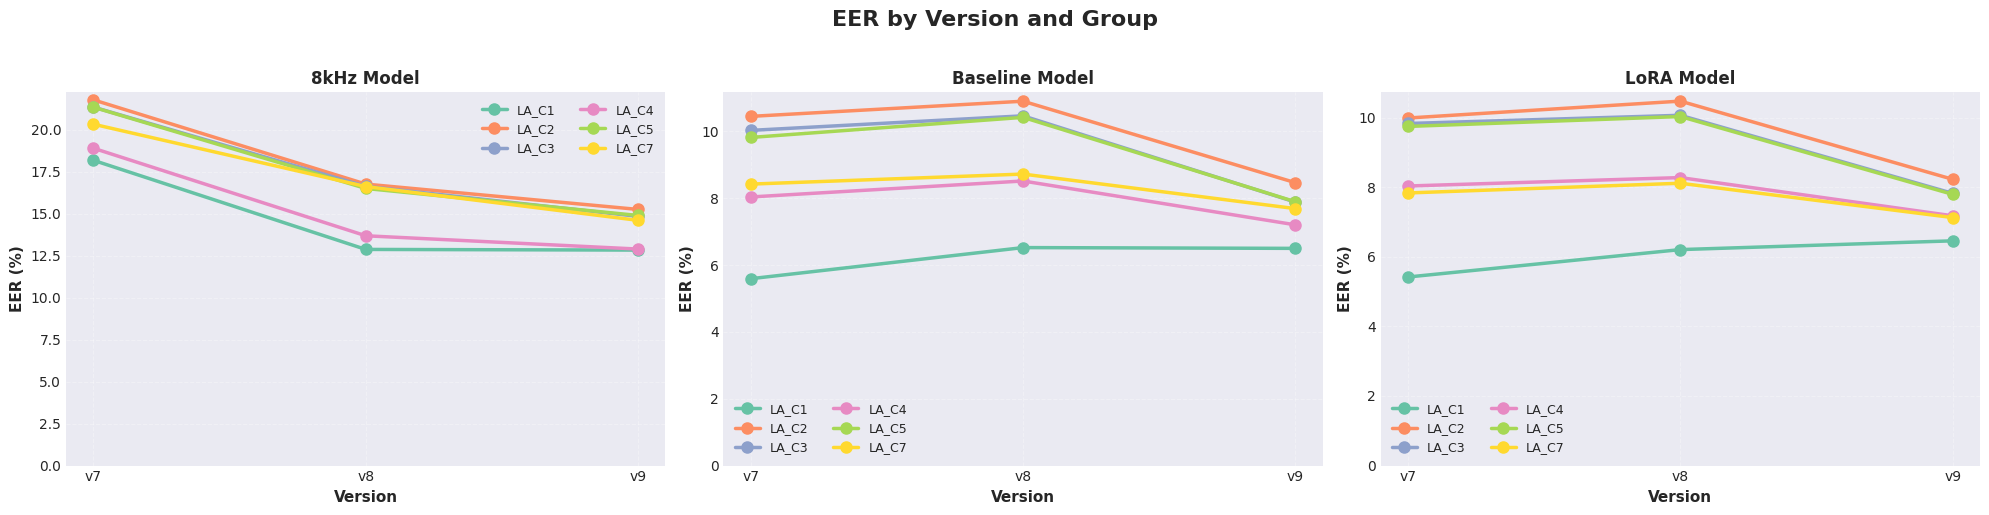

In [16]:
# Graph 1: EER by Version and Group (Separated by Model for clarity)
print(f"\nCreating EER graph...")
print(f"Models to plot: {models}")
print(f"Groups to plot: {groups}")

# Automatically calculate subplot layout based on number of models
n_models = len(models)
n_cols = min(3, n_models)  # Max 3 columns
n_rows = (n_models + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
fig.suptitle('EER by Version and Group', fontsize=16, fontweight='bold', y=1.02)

# Handle both single subplot and array of subplots
if n_models == 1:
    axes = [axes]
elif n_rows == 1:
    axes = axes if isinstance(axes, list) else [axes]
else:
    axes = axes.flatten()

for model_idx, model in enumerate(models):
    model_data = results_df[results_df['model'] == model].sort_values(['group', 'version_short'])
    print(f"\nModel {model}: {len(model_data)} rows")
    ax = axes[model_idx]
    
    for group_idx, group in enumerate(groups):
        group_data = model_data[model_data['group'] == group].sort_values('version_short')
        if len(group_data) > 0:
            print(f"  Group {group}: {len(group_data)} rows, versions: {group_data['version_short'].tolist()}, EER values: {group_data['eer'].tolist()}")
            ax.plot(group_data['version_short'], group_data['eer'], 
                   marker='o', linewidth=2.5, markersize=8,
                   label=group, color=group_colors[group_idx])
        else:
            print(f"  Group {group}: NO DATA!")
    
    ax.set_xlabel('Version', fontsize=11, fontweight='bold')
    ax.set_ylabel('EER (%)', fontsize=11, fontweight='bold')
    ax.set_title(model_names[model], fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9, ncol=2)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(bottom=0)

# Hide unused subplots if any
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()



Creating Accuracy graph...

Model xlsr_conformertcm_mdt_8khz: 18 rows
  Group LA_C1: 3 rows, versions: ['v7', 'v8', 'v9'], Accuracy values: [67.83461538461538, 75.43194444444444, 77.10436739168061]
  Group LA_C2: 3 rows, versions: ['v7', 'v8', 'v9'], Accuracy values: [70.18076923076923, 77.71111111111111, 79.11402142348891]
  Group LA_C3: 3 rows, versions: ['v7', 'v8', 'v9'], Accuracy values: [70.76538461538462, 78.15694444444445, 80.06307813611801]
  Group LA_C4: 3 rows, versions: ['v7', 'v8', 'v9'], Accuracy values: [66.63269230769231, 74.3125, 76.75243754687591]
  Group LA_C5: 3 rows, versions: ['v7', 'v8', 'v9'], Accuracy values: [70.78846153846153, 78.16805555555555, 80.02942364276237]
  Group LA_C7: 3 rows, versions: ['v7', 'v8', 'v9'], Accuracy values: [69.89615384615384, 76.81805555555556, 79.77557260716553]

Model xlsr_conformertcm_mdt_baseline: 18 rows
  Group LA_C1: 3 rows, versions: ['v7', 'v8', 'v9'], Accuracy values: [93.57884615384616, 92.76666666666667, 92.857554952979

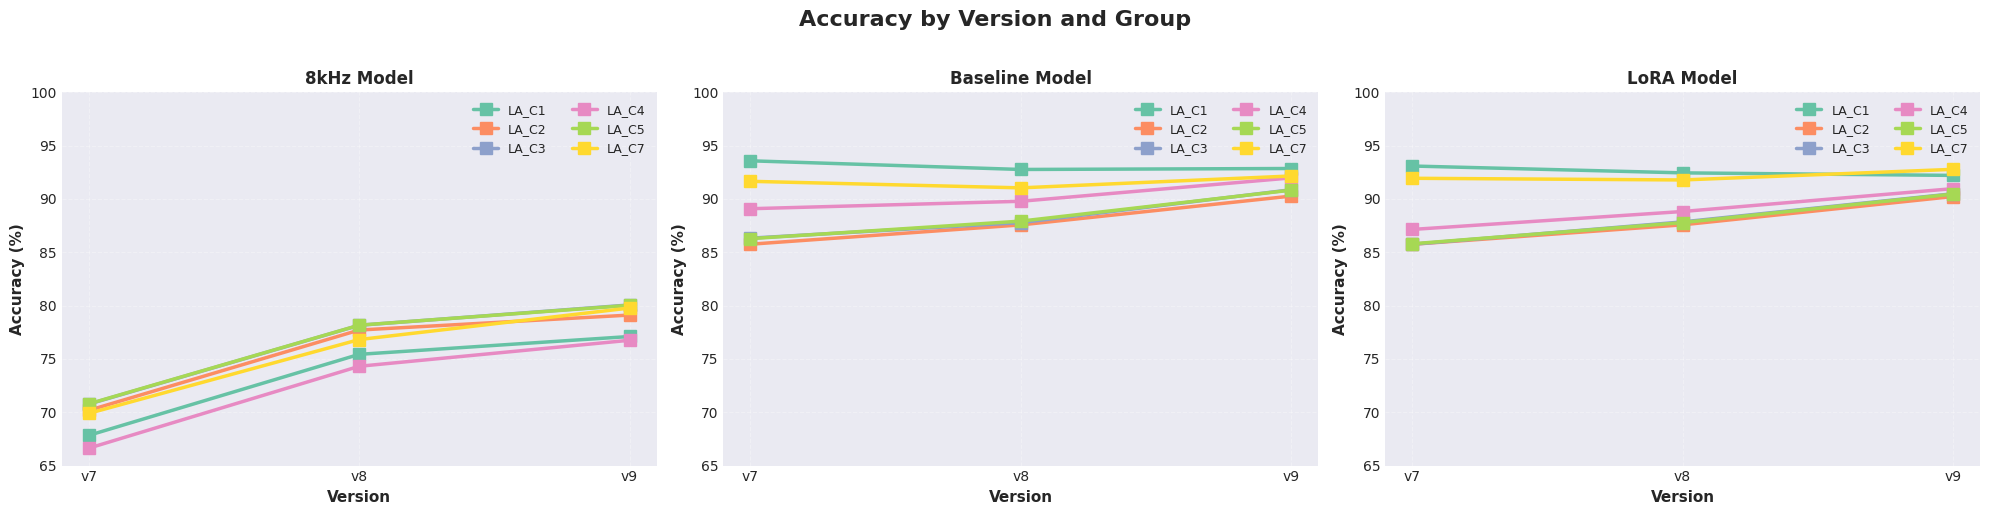

In [20]:
# Graph 2: Accuracy by Version and Group (Separated by Model for clarity)
print(f"\nCreating Accuracy graph...")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Accuracy by Version and Group', fontsize=16, fontweight='bold', y=1.02)

for model_idx, model in enumerate(models):
    model_data = results_df[results_df['model'] == model].sort_values(['group', 'version_short'])
    print(f"\nModel {model}: {len(model_data)} rows")
    ax = axes[model_idx]
    
    for group_idx, group in enumerate(groups):
        group_data = model_data[model_data['group'] == group].sort_values('version_short')
        if len(group_data) > 0:
            print(f"  Group {group}: {len(group_data)} rows, versions: {group_data['version_short'].tolist()}, Accuracy values: {group_data['accuracy'].tolist()}")
            ax.plot(group_data['version_short'], group_data['accuracy'], 
                   marker='s', linewidth=2.5, markersize=8,
                   label=group, color=group_colors[group_idx])
        else:
            print(f"  Group {group}: NO DATA!")
    
    ax.set_xlabel('Version', fontsize=11, fontweight='bold')
    ax.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
    ax.set_title(model_names[model], fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9, ncol=2)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(bottom=65, top=100)

plt.tight_layout()
plt.show()


/tmp/ipykernel_1054668/1035493010.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  eer_pivot = model_data.pivot_table(values='eer', index='group', columns='version_short', aggfunc='first')
/tmp/ipykernel_1054668/1035493010.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  acc_pivot = model_data.pivot_table(values='accuracy', index='group', columns='version_short', aggfunc='first')
/tmp/ipykernel_1054668/1035493010.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  eer_pivot = model_data.pivot_tab

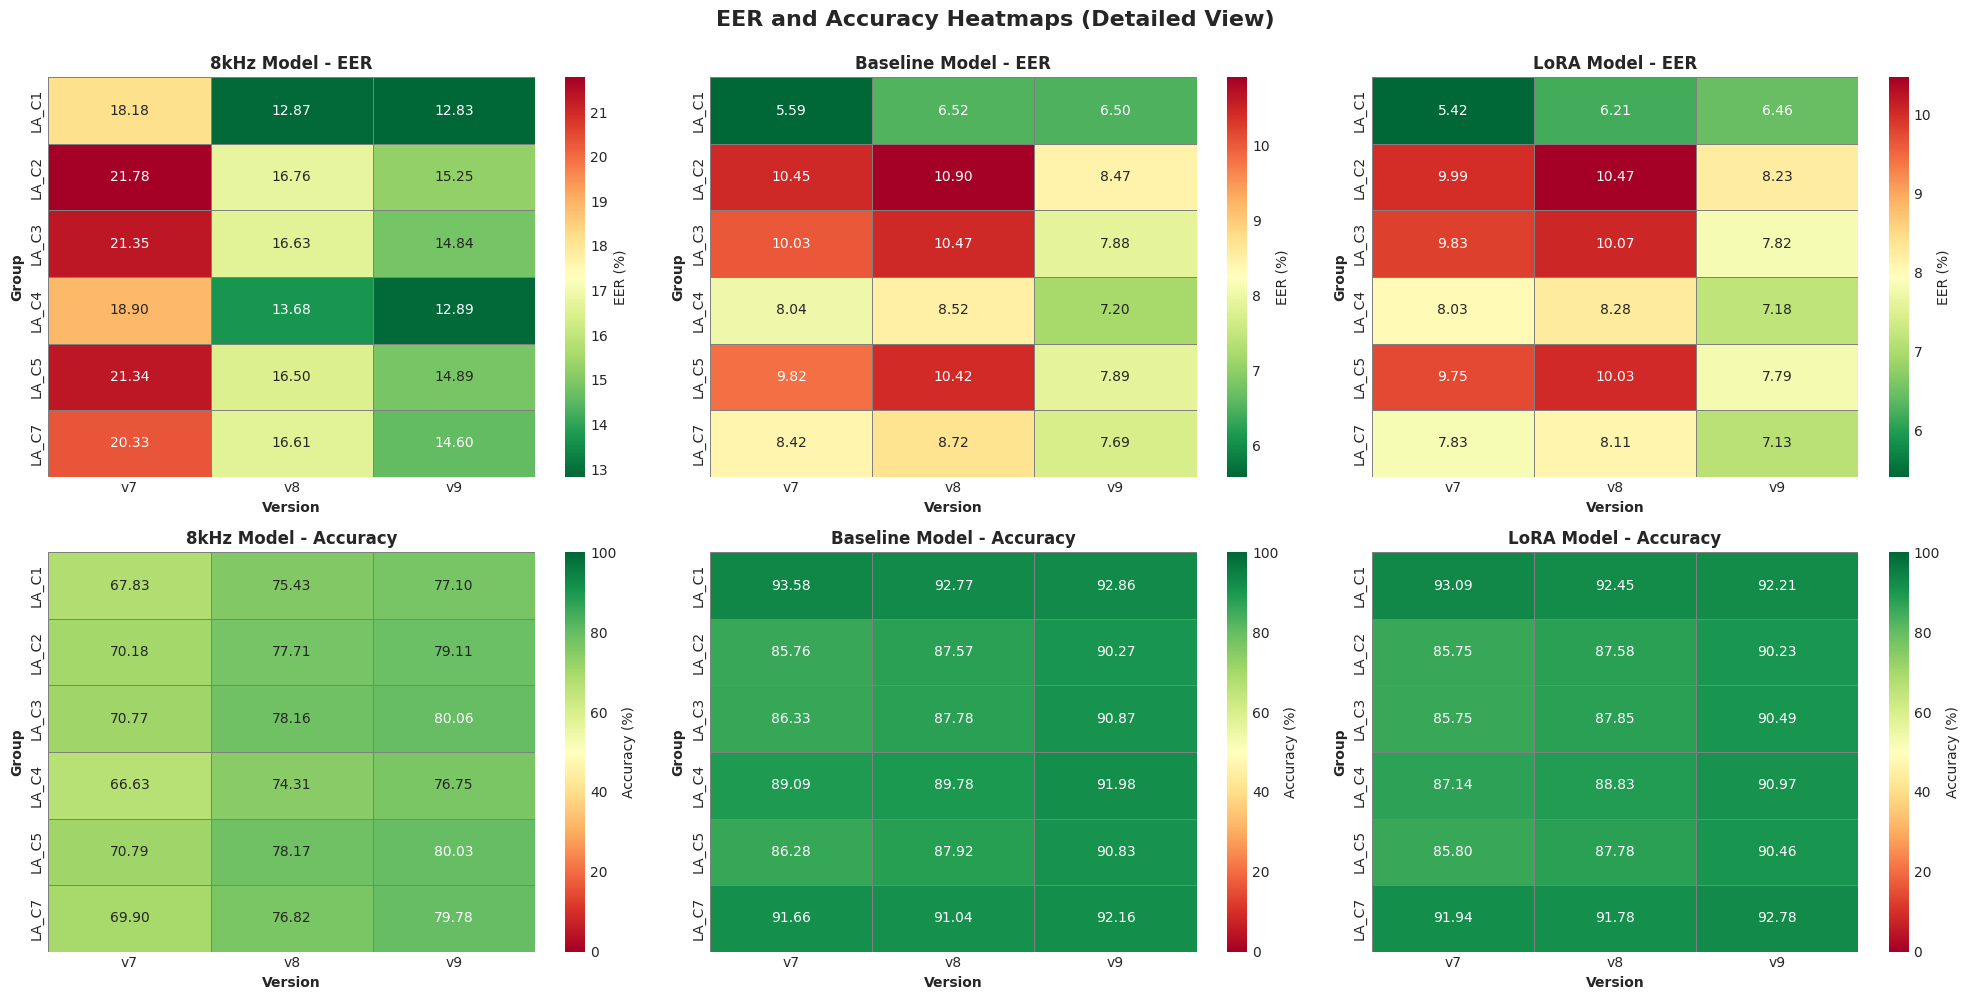

In [18]:
# Optional: Heatmap visualization for detailed comparison
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('EER and Accuracy Heatmaps (Detailed View)', fontsize=16, fontweight='bold', y=0.995)

for model_idx, model in enumerate(models):
    model_data = results_df[results_df['model'] == model]
    
    # Create pivot tables
    eer_pivot = model_data.pivot_table(values='eer', index='group', columns='version_short', aggfunc='first')
    acc_pivot = model_data.pivot_table(values='accuracy', index='group', columns='version_short', aggfunc='first')
    
    # EER Heatmap (lower is better - use reversed colormap)
    ax_eer = axes[0, model_idx]
    if not eer_pivot.empty and eer_pivot.notna().any().any():
        sns.heatmap(eer_pivot, annot=True, fmt='.2f', cmap='RdYlGn_r', 
                    ax=ax_eer, cbar_kws={'label': 'EER (%)'}, 
                    linewidths=0.5, linecolor='gray')
    else:
        ax_eer.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax_eer.transAxes)
    ax_eer.set_title(f'{model_names[model]} - EER', fontsize=12, fontweight='bold')
    ax_eer.set_xlabel('Version', fontsize=10, fontweight='bold')
    ax_eer.set_ylabel('Group', fontsize=10, fontweight='bold')
    
    # Accuracy Heatmap (higher is better)
    ax_acc = axes[1, model_idx]
    if not acc_pivot.empty and acc_pivot.notna().any().any():
        sns.heatmap(acc_pivot, annot=True, fmt='.2f', cmap='RdYlGn', 
                    ax=ax_acc, cbar_kws={'label': 'Accuracy (%)'}, 
                    linewidths=0.5, linecolor='gray', vmin=0, vmax=100)
    else:
        ax_acc.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax_acc.transAxes)
    ax_acc.set_title(f'{model_names[model]} - Accuracy', fontsize=12, fontweight='bold')
    ax_acc.set_xlabel('Version', fontsize=10, fontweight='bold')
    ax_acc.set_ylabel('Group', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
